In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()
    
def calcular_dft_centrada(imagen_grayscale):
    dft = cv2.dft(np.float32(imagen_grayscale), flags=cv2.DFT_COMPLEX_OUTPUT)
    return np.fft.fftshift(dft)
    
def mostrar_frecuencias(imagen_grayscale, dft_shift, mostrar_fase=False, titulo='', titulo_magnitud='Espectro de magnitud'):
    real = dft_shift[:, :, 0]
    imag = dft_shift[:, :, 1]
    magnitud = 20 * np.log1p(np.sqrt(real**2 + imag**2))

    if mostrar_fase:
        fase = np.angle(real + 1j * imag)

    n_subplots = 3 if mostrar_fase else 2
    plt.figure(figsize=(12, 4 if not mostrar_fase else 6))

    plt.subplot(1, n_subplots, 1)
    plt.imshow(imagen_grayscale, cmap='gray')
    plt.title('Imagen original' + (f' - {titulo}' if titulo else ''))
    plt.axis('off')

    plt.subplot(1, n_subplots, 2)
    plt.imshow(magnitud, cmap='gray')
    plt.title(titulo_magnitud)
    plt.axis('off')

    if mostrar_fase:
        plt.subplot(1, n_subplots, 3)
        plt.imshow(fase, cmap='gray')
        plt.title('Fase')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    
def reconstruir_imagen_idft(dft_shift, mostrar=False, titulo="Imagen Reconstruida"):
    # Paso 1: Desplazar frecuencias nuevamente
    dft_ishift = np.fft.ifftshift(dft_shift)

    # Paso 2: Aplicar IDFT
    img_back = cv2.idft(dft_ishift)

    # Paso 3: Obtener la magnitud (real e imaginario)
    img_recuperada = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Paso 4: Normalizar al rango [0, 255]
    img_recuperada = cv2.normalize(img_recuperada, None, 0, 255, cv2.NORM_MINMAX)
    img_recuperada = np.uint8(img_recuperada)

    # Mostrar si se solicita
    if mostrar:
        plt.figure(figsize=(5, 5))
        plt.imshow(img_recuperada, cmap='gray')
        plt.title(titulo)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return img_recuperada

def crear_mascara_frecuencia(shape, radio, tipo='pasa_bajas', forma='circular'):
    filas, columnas = shape
    centro_fila, centro_columna = filas // 2, columnas // 2

    Y, X = np.ogrid[:filas, :columnas]

    if forma == 'circular':
        distancia = np.sqrt((X - centro_columna)**2 + (Y - centro_fila)**2)
        if tipo == 'pasa_bajas':
            mascara = distancia <= radio
        elif tipo == 'pasa_altas':
            mascara = distancia > radio
        else:
            raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")
    elif forma == 'cuadrada':
        mitad_lado = radio
        mascara = np.zeros((filas, columnas), dtype=bool)
        if tipo == 'pasa_bajas':
            mascara[
                centro_fila - mitad_lado:centro_fila + mitad_lado,
                centro_columna - mitad_lado:centro_columna + mitad_lado
            ] = True
        elif tipo == 'pasa_altas':
            mascara[:, :] = True
            mascara[
                centro_fila - mitad_lado:centro_fila + mitad_lado,
                centro_columna - mitad_lado:centro_columna + mitad_lado
            ] = False
        else:
            raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")
    else:
        raise ValueError("Forma debe ser 'circular' o 'cuadrada'")

    # Repetimos para los dos canales (real, imaginario)
    return np.repeat(mascara[:, :, np.newaxis], 2, axis=2).astype(np.float32)

**10. (*) Responder las siguientes preguntas. Tratar de utilizar dos imagenes en aquellos ejercicios que no
soliciten algo particular. Utilizar una imagen que muestre frecuencias bajas en su mayorıa y otras
con mayorıa de frecuencias altas. Por cada pregunta se ha agregado una sugerencia de como realizar
el ejercicio practico para acompañar su respuesta.**

## 11)
**11. Transformada de Fourier inversa: Realiza la transformada de Fourier inversa para recuperar la imagen
original a partir de su version filtrada en el dominio frecuencial. Compara la imagen original con la
imagen recuperada.**


Al realizar la transformada inversa se obtiene la imagen original con la cual se generaron las magnitudes de las frecuencias. Esto deberia ser siempre asi siempre y cuando no se hayan realizado alteraciones a las frecuencias.

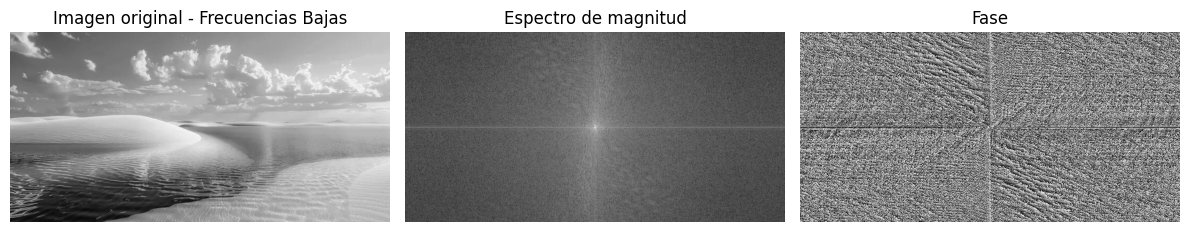

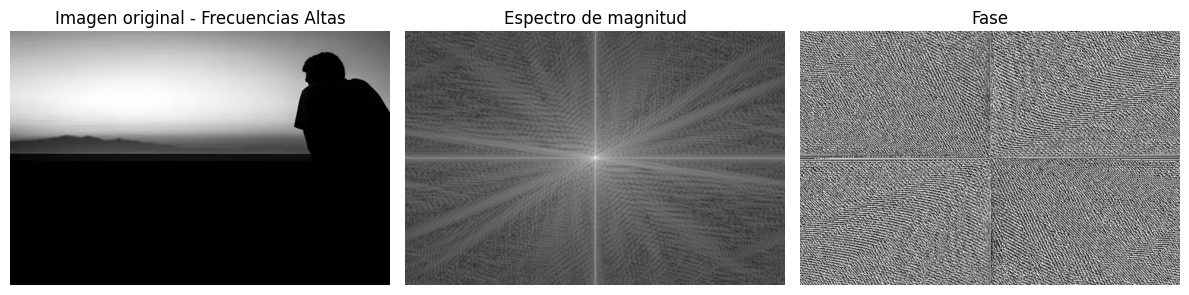

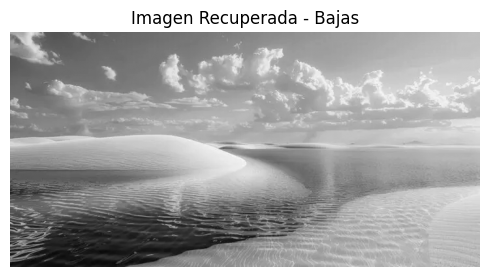

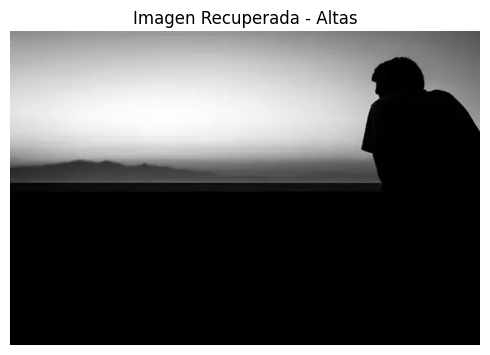

In [26]:
# Cargar imágenes
img_frecuencias_bajas = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_frecuencias_altas = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Calcular DFT centrado
dft_shift_bajas = calcular_dft_centrada(img_frecuencias_bajas)
dft_shift_altas = calcular_dft_centrada(img_frecuencias_altas)

# Mostrar espectros
mostrar_frecuencias(img_frecuencias_bajas, dft_shift_bajas, mostrar_fase=True, titulo='Frecuencias Bajas')
mostrar_frecuencias(img_frecuencias_altas, dft_shift_altas, mostrar_fase=True, titulo='Frecuencias Altas')

# Reconstrucción inversa
img_recuperada_bajas = reconstruir_imagen_idft(dft_shift_bajas, mostrar=True, titulo='Imagen Recuperada - Bajas')
img_recuperada_altas = reconstruir_imagen_idft(dft_shift_altas, mostrar=True, titulo='Imagen Recuperada - Altas')




## a)
**(a) ¿Como se visualiza la diferencia entre las frecuencias altas y bajas en una imagen? Ejercicio sugerido: Aplicar la Transformada de Fourier (DFT) y mostrar la magnitud del espectro centrado con fftshift.**

Se puede obervar una clara diferencia entre las imagenes posteriormente usadas en el dominio frecuencial. Por un lado, la imagen del bosque posee transiciones de colores mas suaves y no hay cambios o lineas tan marcas dentro de la imagen (las lineas que mas destacan son los troncos de los arboles). 

Esto se ve representado en el dominio frecuencial medinte una acumulacion de las frecuencias bajas en el centro de la imagen. Por el otro lado, en la otra imagen se puede apreciar que tiene muchas frecuencias altas ya que la imagen del paisaje tiene grandes lineas y bordes que marcan un cambio abrupto en el color de la imagen. Esto se ve representado en el espectro frecuencial como unos rayos o lineas que no se encuentran tan centrados en la region central de la representacion de las magnitudes frecuencias.  

## (b)
**(b) ¿Que ocurre si eliminamos las componentes de alta frecuencia de una imagen? ¿Y si eliminamos
las de baja frecuencia? Ejercicio sugerido: Aplicar filtros pasa bajos y pasa altos en el dominio
de la frecuencia y reconstruir la imagen con la transformada inversa.**

Al eliminar las componentes de alta frecuencia provocamos que la imagen se vuelva mas "suave" en el sentido de que se empizan a distorsionar algunos bordes o detalles mas finos de la imagen ya que estos representan los cambios mas bruscos dentro de la imagen. Generalmente esto se hace cuando se quiere crear un efecto de desenfoque, se quiere reducir el ruido o se quiere realizar una compresion de la imagen.

Por el otro lado, si eliminamos las frecuencias bajas de la imagen se van a mostrar principalmente los bordes y contornos de la misma con y sacando los colores dentro de los objetos. Se usa principalmente para marcar bordes o detalles dentro de la imagen.

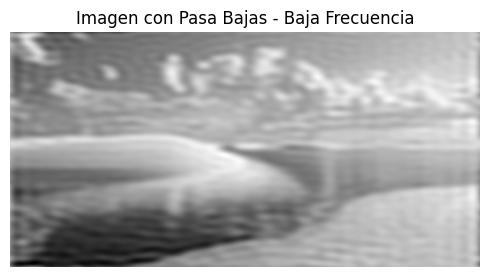

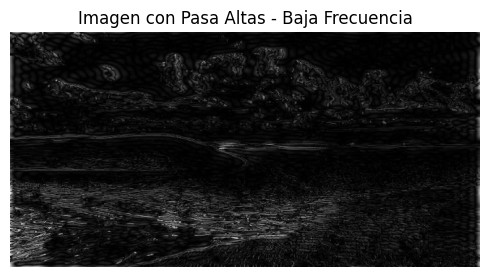

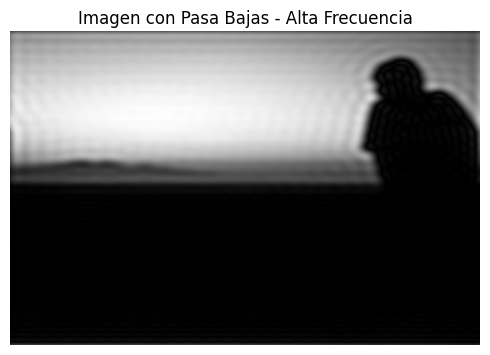

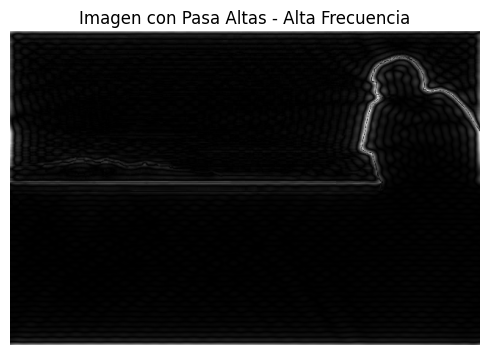

In [ ]:
# 1. Cargar imagen en escala de grises
img_baja_frec = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_alta_frec = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# 2. Obtener el DFT centrado
dft_shift_bajas = calcular_dft_centrada(img_baja_frec)
dft_shift_altas = calcular_dft_centrada(img_alta_frec)

# 3. Crear máscaras para filtros
radio = 30  # Radio del filtro en píxeles
mascara_pasa_bajas_frecB = crear_mascara_frecuencia(img_baja_frec.shape, radio, tipo='pasa_bajas')
mascara_pasa_altas_frecB = crear_mascara_frecuencia(img_baja_frec.shape, radio, tipo='pasa_altas')
mascara_pasa_bajas_frecA = crear_mascara_frecuencia(img_alta_frec.shape, radio, tipo='pasa_bajas')
mascara_pasa_altas_frecA = crear_mascara_frecuencia(img_alta_frec.shape, radio, tipo='pasa_altas')

# 4. Aplicar filtros en frecuencia
dft_bajas_frecB = dft_shift_bajas * mascara_pasa_bajas_frecB
dft_altas_frecB = dft_shift_bajas * mascara_pasa_altas_frecB
dft_bajas_frecA = dft_shift_altas * mascara_pasa_bajas_frecA
dft_altas_frecA = dft_shift_altas * mascara_pasa_altas_frecA


# 5. Reconstrucción en el dominio espacial
img_bajas = reconstruir_imagen_idft(dft_bajas_frecB, mostrar=True, titulo='Imagen con Pasa Bajas - Baja Frecuencia')
img_altas = reconstruir_imagen_idft(dft_altas_frecB, mostrar=True, titulo='Imagen con Pasa Altas - Baja Frecuencia')
img_bajas_frecA = reconstruir_imagen_idft(dft_bajas_frecA, mostrar=True, titulo='Imagen con Pasa Bajas - Alta Frecuencia')
img_altas_frecA = reconstruir_imagen_idft(dft_altas_frecA, mostrar=True, titulo='Imagen con Pasa Altas - Alta Frecuencia')



## (c)
**(c) ¿Que representa la fase de la transformada de Fourier de una imagen? ¿Que ocurre si se conserva
solo la fase o solo la magnitud? Ejercicio sugerido: Reconstruir una imagen usando solo la
magnitud y fase de otra imagen, intercambiar fase y magnitud entre dos imagenes distintas.**

La fase es la encargad de codificar la localizacion espacial de los distintos objetos dentro de la imagen, que con ayuda de la magnitud, forman a la imagen final. A la hora de reconstruir una imagen solo con la fase se puede observar que la mayoria de las formas, contornos y bordes se mantienen y se puede observar cierta semenjanza con la imagen original pero con los colores y tonalidades totalmente alterados. Cuando reconstruimos utilizando solo la magnitud la reconstruccion es una imagen totalmente lisa y sin color.

Cuando realizamos el experimento de intercambiar la fase y magnitud de 2 imagenes obtenemos que cuando mantenemos la magnitud pero cambiamos la fase, la imagen resultante tendra los colores, intensidades y texturas de originales pero tomando las formas y contornos de la segunda imagen. Cuando hacemos el caso contrario y mantenemos la fase e intercambiamos la magnitud se mantienen a grandes rasgos los contornos y detalles pero los colores y tonalidades se ven alterados. 

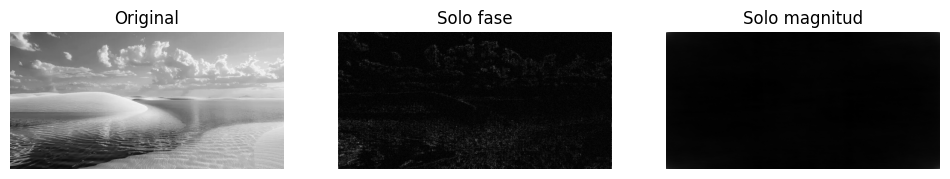

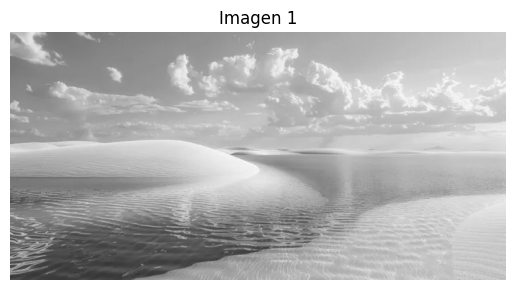

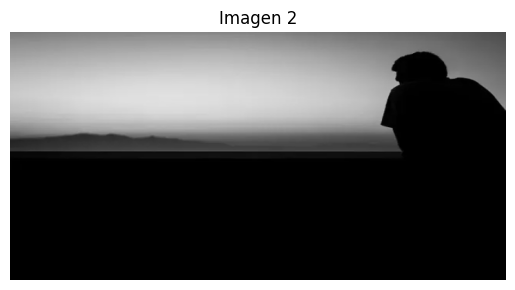

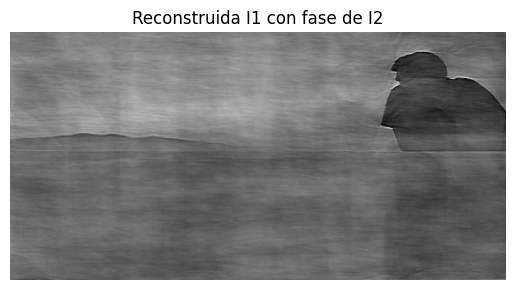

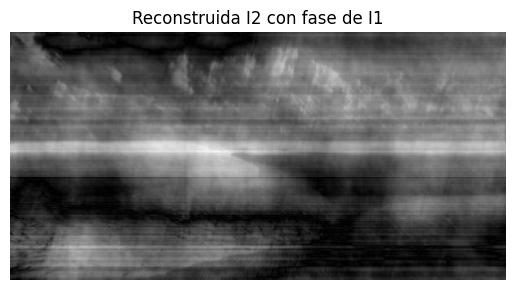

In [33]:
def dft_components(img):
    # 1) DFT
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    # 2) magnitud y fase
    real, imag = dft_shift[:,:,0], dft_shift[:,:,1]
    magnitude = np.sqrt(real**2 + imag**2)
    phase     = np.arctan2(imag, real)
    return magnitude, phase

def idft_from_components(magnitude, phase):
    # 1) recomponer complejo y aplicar ifftshift
    complex_spec = magnitude * np.exp(1j * phase)
    # expandir a par de canales
    real = np.real(complex_spec)
    imag = np.imag(complex_spec)
    combined = np.stack([real, imag], axis=-1)
    shifted  = np.fft.ifftshift(combined)
    # 2) IDFT
    img_back = cv2.idft(shifted)
    img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    # normalizar
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(img_back)

# Cargar dos imágenes
I1 = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
I2 = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Deben tener el mismo tamaño
I2 = cv2.resize(I2, (I1.shape[1], I1.shape[0]))

dft = cv2.dft(np.float32(I1), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Obtener magnitud y fase
real, imag = dft_shift[:, :, 0], dft_shift[:, :, 1]
magnitude = np.sqrt(real**2 + imag**2)
phase = np.arctan2(imag, real)

# === Solo FASE ===
# Usamos magnitud uniforme (todas las frecuencias con igual peso)
mag_uniforme = np.ones_like(magnitude)
recon_fase = idft_from_components(mag_uniforme, phase)

# === Solo MAGNITUD ===
# Usamos fase nula (todos los vectores alineados)
fase_nula = np.zeros_like(phase)
recon_magnitud = idft_from_components(magnitude, fase_nula)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(I1, cmap='gray'), plt.title("Original"), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(recon_fase, cmap='gray'), plt.title("Solo fase"), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(recon_magnitud, cmap='gray'), plt.title("Solo magnitud"), plt.axis('off')
plt.show()

# Extraer componentes
A1, Phi1 = dft_components(I1)
A2, Phi2 = dft_components(I2)

# Reconstruir combinaciones
R1 = idft_from_components(A1, Phi2)  # magnitud de I1 + fase de I2
R2 = idft_from_components(A2, Phi1)  # magnitud de I2 + fase de I1

show_image(I1, 'Imagen 1')
show_image(I2, 'Imagen 2')
show_image(R1, 'Reconstruida I1 con fase de I2')
show_image(R2, 'Reconstruida I2 con fase de I1')


## (d)
**(d) ¿Por que se centra la transformada de Fourier para su visualizacion? ¿Que efecto tiene? Ejercicio
sugerido: Mostrar el espectro de magnitud con y sin aplicar fftshift.**

La transformada de fourier se centra para su visualizacion ya que por defecto la implementacion de la DFT coloca las frecuencias bajas en las esquinas y las frecuencias altas en el centro. Esto no es muy intuitivo a la hora de realizar el analisis de la imagen ya que al centrar las frecuencias bajas en el centro podemos ver de forma mas rapida e intuitiva si la imagen tiene predominio de frecuencias bajas o altas. Ademas, al centrar las frecuencias bajas en el centro, se facilita la aplicacion de mascaras o efectos visuales a las imagenes.

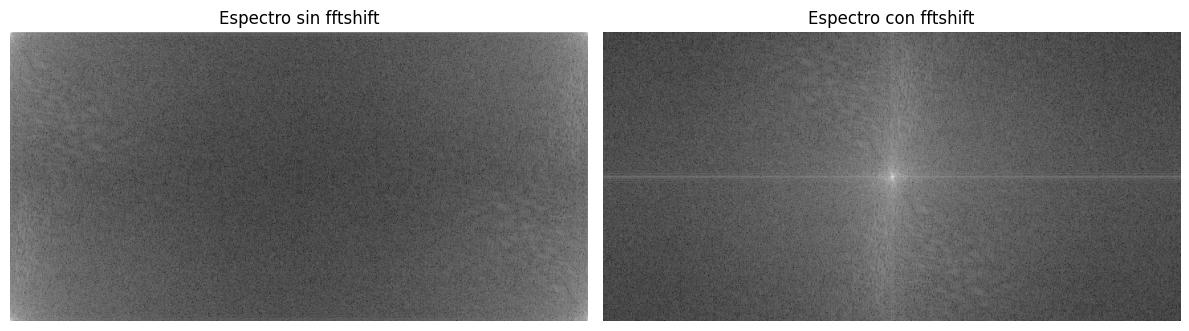

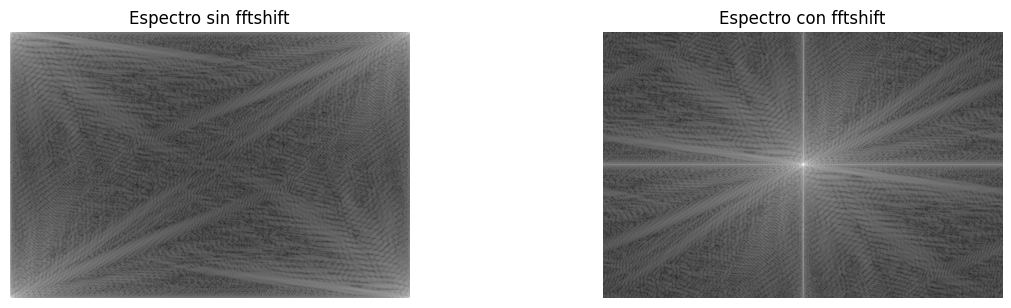

In [36]:
# 1. Cargar imagen en escala de grises
img_baja = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_alta = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# 2. Aplicar DFT
dft_baja = cv2.dft(np.float32(img_baja), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_alta = cv2.dft(np.float32(img_alta), flags=cv2.DFT_COMPLEX_OUTPUT)

# 3. Calcular espectro sin shift
mag_no_shift_baja = 20 * np.log1p(cv2.magnitude(dft_baja[:, :, 0], dft_baja[:, :, 1]))
mag_no_shift_alta = 20 * np.log1p(cv2.magnitude(dft_alta[:, :, 0], dft_alta[:, :, 1]))

# 4. Calcular espectro con shift
dft_shift_baja = np.fft.fftshift(dft)
mag_shift_baja = 20 * np.log1p(cv2.magnitude(dft_shift_baja[:, :, 0], dft_shift_baja[:, :, 1]))
dft_shift_alta = np.fft.fftshift(dft_alta)
mag_shift_alta = 20 * np.log1p(cv2.magnitude(dft_shift_alta[:, :, 0], dft_shift_alta[:, :, 1]))

# 5. Mostrar lado a lado
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(mag_no_shift_baja, cmap='gray')
plt.title('Espectro sin fftshift')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag_shift_baja, cmap='gray')
plt.title('Espectro con fftshift')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(mag_no_shift_alta, cmap='gray')
plt.title('Espectro sin fftshift')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mag_shift_alta, cmap='gray')
plt.title('Espectro con fftshift')
plt.axis('off')

plt.tight_layout()
plt.show()

## (e)
**(e) ¿Como se comporta la transformada de Fourier ante la traslacion o rotacion de una imagen?
Ejercicio sugerido: Aplicar una traslacion o rotacion y comparar los espectros de magnitud y
fase antes y despues.**

A la hora de aplicar una traslacion se puede apreciar un cambio en la fase de la imagen en los cuales se pueden apreciar ciertos patrones de ondas en las direccion en la cual se realizo la traslacion. La magnitud en teoria deberia mantenerse de la misma manera que antes de la traslacion ya que no se ve afectado el contenido de la imagen. Sin embargo, al realizar la traslacion parte de la imagen sale del recuadro de la misma generando un espacio en negro y, por lo tanto, creando bordes y alteraciones a los colores.

Por el otro lado, cuando realizamos una rotacion se ven alteradas tanto la magnitud como la fase. La fase muestra de forma espacial hacia donde se realizo la rotacion dejando un patron mas marcado e intenso. Por su parte, la magnitud tambien muestra la rotacion aplicada a la imagen y en este caso, tambien incrementan las frecuencias altas debido a la aparicion de un fondo negro (y por lo tanto nuevos bordes) en aquellos lugares donde la imagen no esta presente debido a la rotacion.

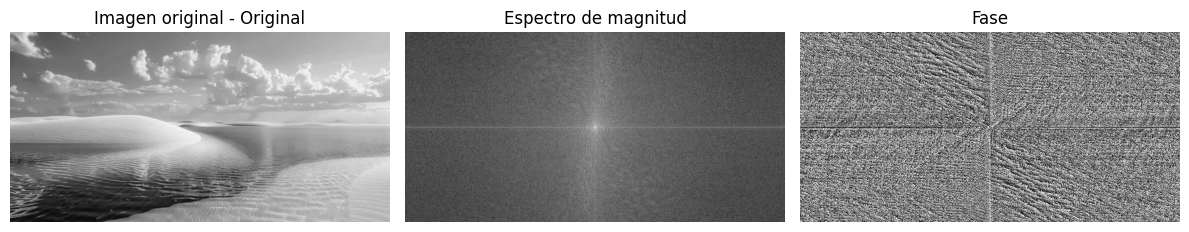

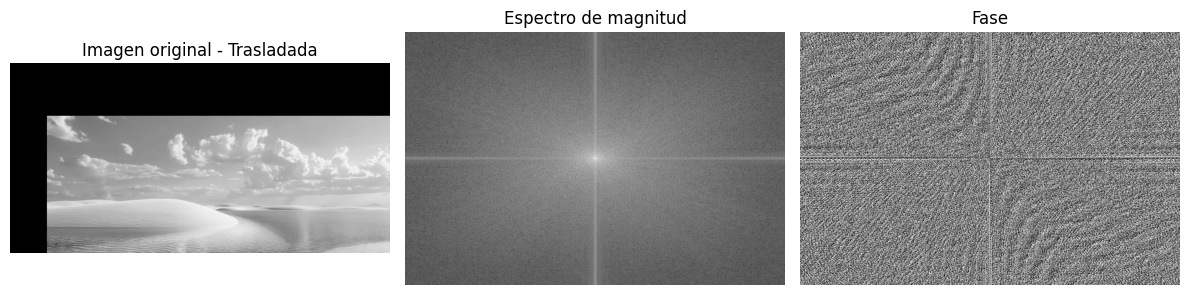

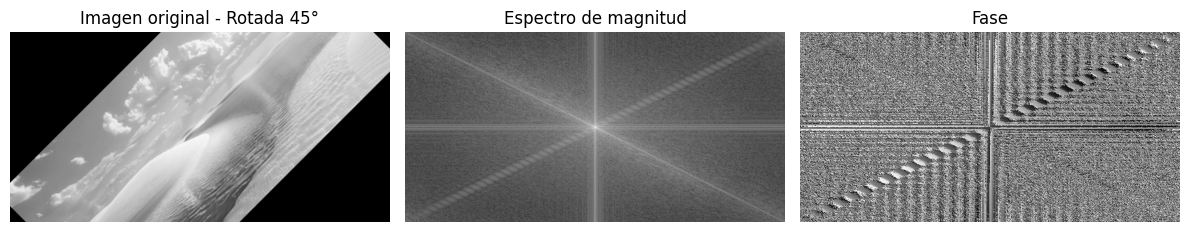

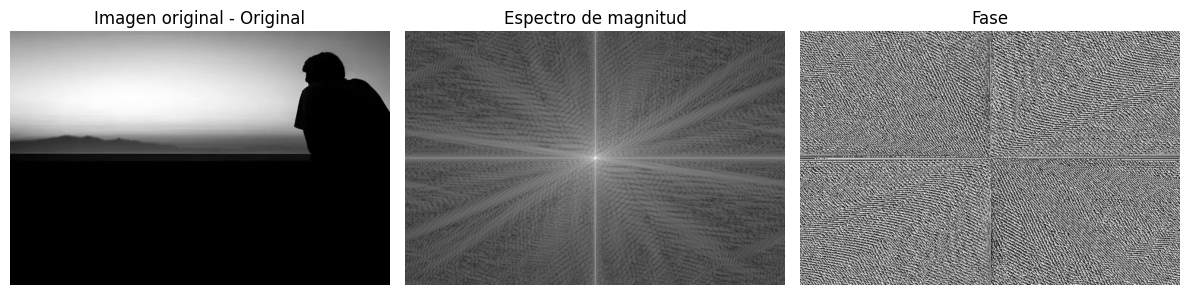

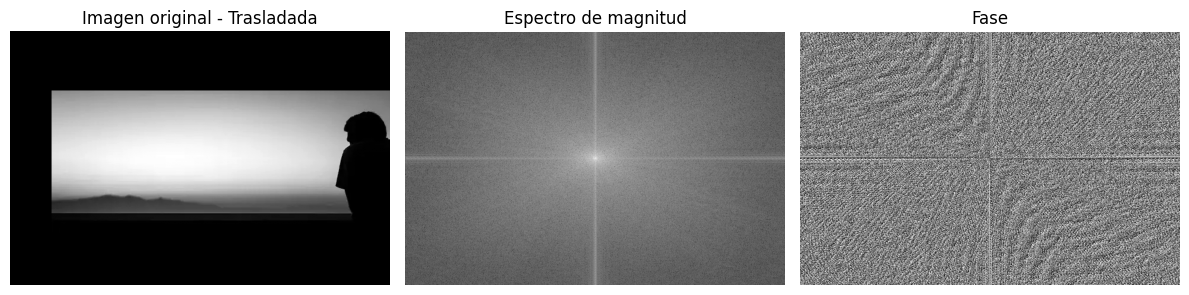

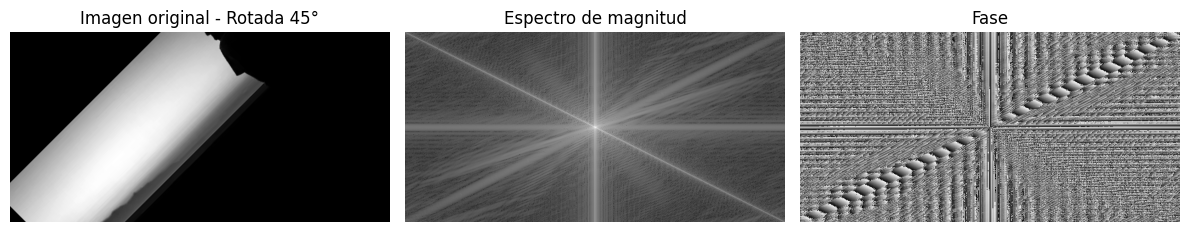

In [12]:
# Cargar imagen original
img_baja = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_alta = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Trasladar con warpAffine
M = np.float32([[1, 0, 70], [0, 1, 100]])  # desplazamiento (70, 100)
img_shift_baja = cv2.warpAffine(img_baja, M, (img_baja.shape[1], img_baja.shape[0]))
img_shift_alta = cv2.warpAffine(img_alta, M, (img_alta.shape[1], img_alta.shape[0]))

# Rotar 45°
h, w = img_baja.shape
M_rot = cv2.getRotationMatrix2D((w/2, h/2), 45, 1.0)
img_rot_baja = cv2.warpAffine(img_baja, M_rot, (w, h))
img_rot_alta = cv2.warpAffine(img_alta, M_rot, (w, h))

# Calcular DFT centrado de ambas
dft_orig_baja = calcular_dft_centrada(img_baja)
dft_shift_baja = calcular_dft_centrada(img_shift_baja)
dft_rot_baja  = calcular_dft_centrada(img_rot_baja)

dft_orig_alta = calcular_dft_centrada(img_alta)
dft_shift_alta = calcular_dft_centrada(img_shift_alta)
dft_rot_alta  = calcular_dft_centrada(img_rot_alta)

# Mostrar espectros (magnitud y fase)
mostrar_frecuencias(img_baja, dft_orig_baja, mostrar_fase=True, titulo='Original')
mostrar_frecuencias(img_shift_baja, dft_shift, mostrar_fase=True, titulo='Trasladada')
mostrar_frecuencias(img_rot_baja, dft_rot_baja, mostrar_fase=True, titulo='Rotada 45°')

mostrar_frecuencias(img_alta, dft_orig_alta, mostrar_fase=True, titulo='Original')
mostrar_frecuencias(img_shift_alta, dft_shift, mostrar_fase=True, titulo='Trasladada')
mostrar_frecuencias(img_rot_alta, dft_rot_alta, mostrar_fase=True, titulo='Rotada 45°')

## (f)
**(f) ¿Como se refleja una estructura periodica en el dominio frecuencial? Ejercicio sugerido: Usar
imagenes sinteticas (rejillas, lıneas) y observar como se representan sus frecuencias dominantes.**

A la hora de analizar el espacio frecuencial con imagenes que contengan patrones periodicos podemos decir que se pueden observar que tanto en la magnitud como en la fase vamos a encontrar patrones periodicos bien definidos. Dentro de estos patrones se pueden observar caracteristicas importantes como que tanto la fase como la magnitud poseen patrones bastante similares o en algunos casos practicamente identicos. Tambien es importante remarcar que se mantiene cierta proporcionalidad espacial entre la imagen original y el espacio frecuencial. Identificar estos patrones puede ser de gran ayuda a la hora de aplicar filtros o poder distinguir si una imagen ha tenido algun procesamiento previo.

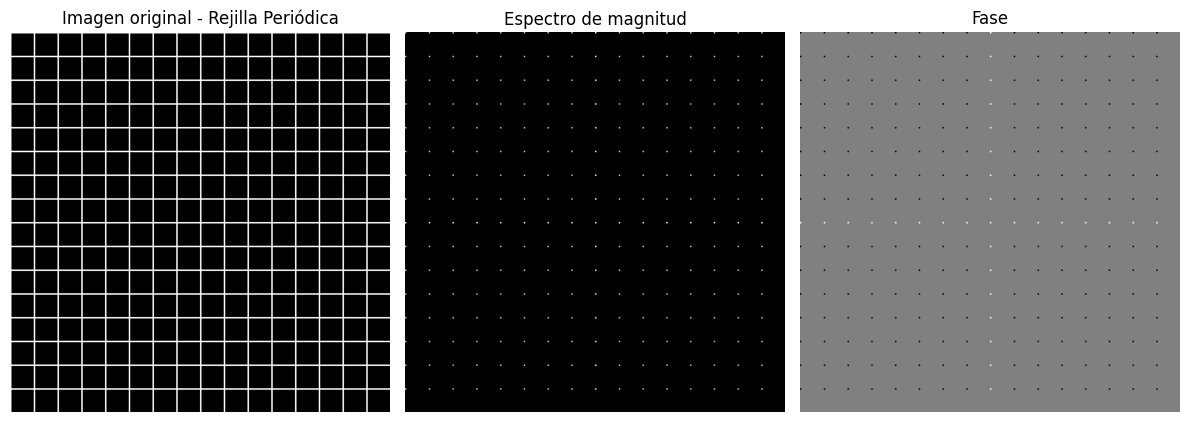

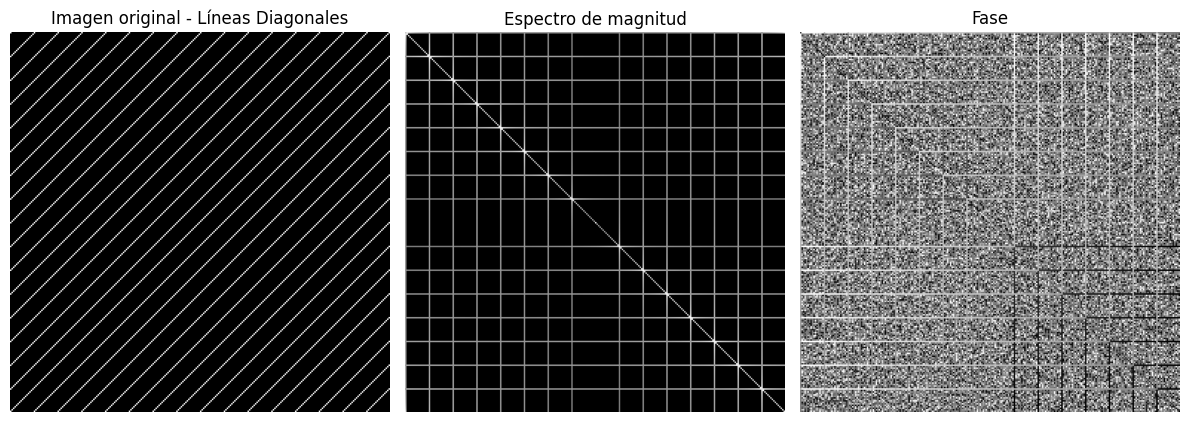

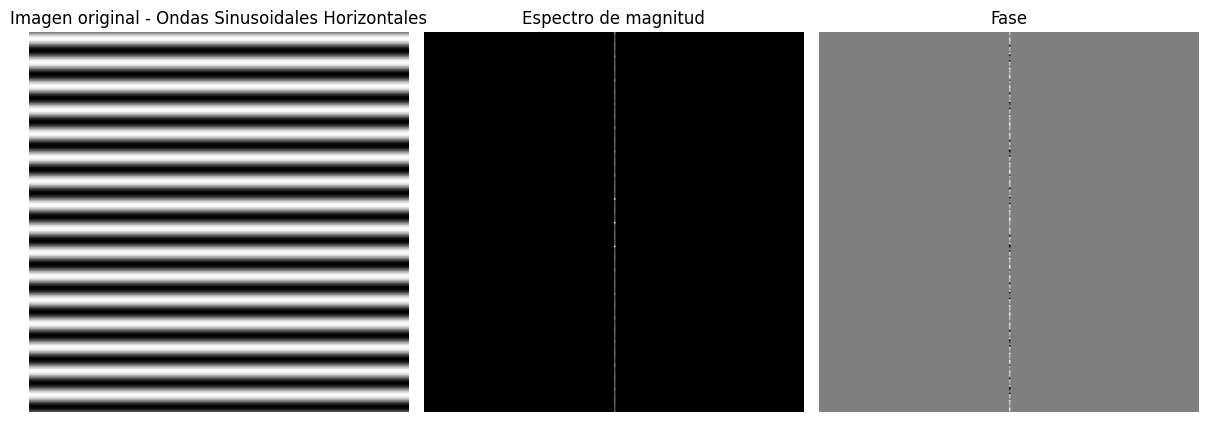

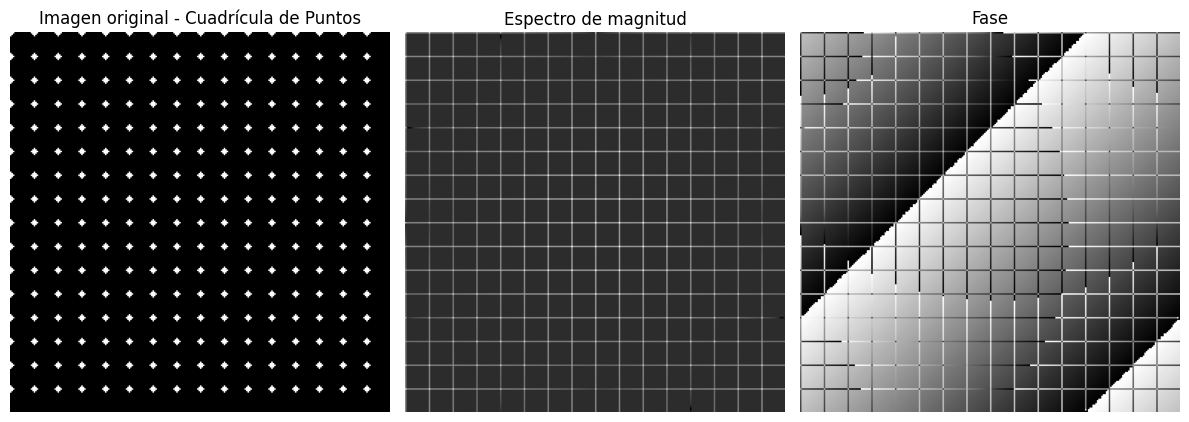

In [ ]:
# Crear imagen sintética: rejilla (líneas horizontales y verticales periódicas)
size = 256
grid = np.zeros((size, size), dtype=np.uint8)
step = 16
grid[::step, :] = 255
grid[:, ::step] = 255

# Crear imagen sintética: líneas diagonales periódicas
lines = np.zeros((size, size), dtype=np.uint8)
for i in range(0, size, step):
    cv2.line(lines, (0, i), (i, 0), 255, 1)
    cv2.line(lines, (i, size-1), (size-1, i), 255, 1)

# Crear imagen sintética: ondas sinusoidales horizontales
sin_pattern = np.zeros((size, size), dtype=np.uint8)
for y in range(size):
    value = 127 + 127 * np.sin(2 * np.pi * y / step)
    sin_pattern[y, :] = value

# Crear imagen sintética: puntos periódicos
dots = np.zeros((size, size), dtype=np.uint8)
for y in range(0, size, step):
    for x in range(0, size, step):
        cv2.circle(dots, (x, y), 2, 255, -1)

# Aplicar DFT centrada y mostrar para todos los patrones
patterns = [
    (grid, 'Rejilla Periódica'),
    (lines, 'Líneas Diagonales'),
    (sin_pattern, 'Ondas Sinusoidales Horizontales'),
    (dots, 'Cuadrícula de Puntos')
]

for img, title in patterns:
    dft_shift = calcular_dft_centrada(img)
    mostrar_frecuencias(img, dft_shift, mostrar_fase=True, titulo=title)

## (g)
**(g) ¿Que diferencias se observan en el espectro de imagenes suaves vs. imagenes con bordes pronunciados? Ejercicio sugerido: Comparar el espectro de una imagen desenfocada vs. la original
con bordes definidos**

Se puede apreciar que cuando aplicamos un suavizado a una imagen con bordes marcadas, su espectro de magnitud pierde en gran medida las componentes altas y concentran mas las componenetes bajas. Esto se debe a que al suavizar toda la imagen los bordes de la misma ya no son tan abruptos y por lo tanto se representan con frecuencias mas bajas.

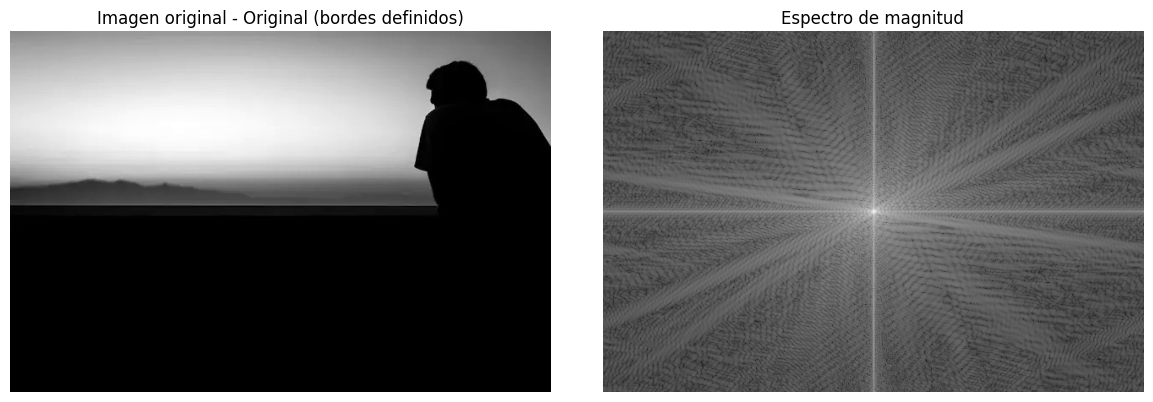

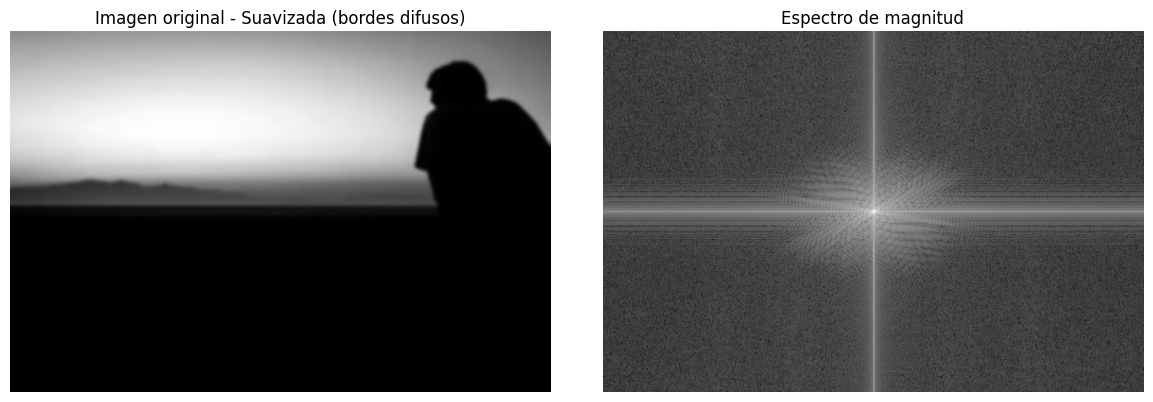

In [10]:
# Cargar la imagen en escala de grises
imagen = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Aplicar un desenfoque (filtro gaussiano)
imagen_suavizada = cv2.GaussianBlur(imagen, (11, 11), sigmaX=0)

# Calcular DFT centrada de ambas
dft_original = calcular_dft_centrada(imagen)
dft_suavizada = calcular_dft_centrada(imagen_suavizada)

# Mostrar imagen original y su espectro
mostrar_frecuencias(imagen, dft_original, mostrar_fase=False, titulo='Original (bordes definidos)')

# Mostrar imagen suavizada y su espectro
mostrar_frecuencias(imagen_suavizada, dft_suavizada, mostrar_fase=False, titulo='Suavizada (bordes difusos)')

## (h)
**(h) ¿Que ocurre si aplicamos un filtro de forma circular o rectangular en el espectro? ¿Como cambia
la imagen? Ejercicio sugerido: Implementar mascaras ideales de paso bajo y paso alto circulares
y cuadradas y observar sus efectos.**

Cuando aplicamos un filtro de pasa baja permitimos que pasen solo aquellas frecuencias ubicadas en el centro (bajas). Esto provoca que en la reconstruccion la imagen se vea borrosa o desenfocada pero mantiene a grandes rasgos la intensidad de colores.

Cuando aplicamos un filtro de pasa baja permitimos que pasen solo aquellas funciones de frecuencias ubicadas en los bordes (altas). Esto provoca que cunado reconstruyamos la imagen se resalten los bordes o cambios mas bruscos dentro de la imagen.

Es importante destacar que al aplicar mascaras que corten abruptamente las magnitudes pueden provocar artefactos en la imagen reconstruida. Es recomendable utilizar mascaras mas suaves.


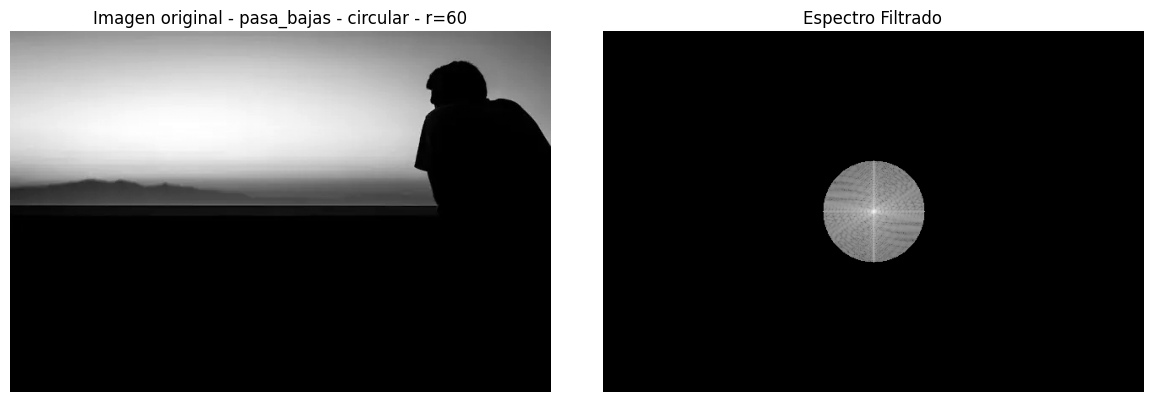

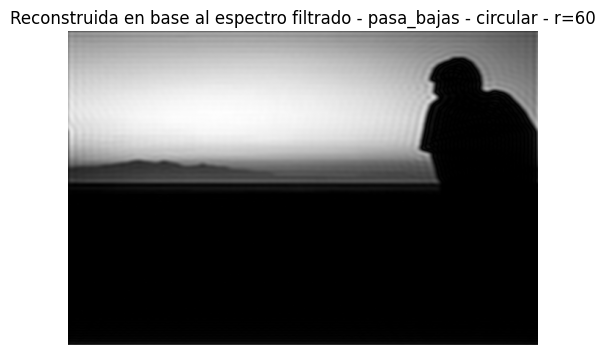

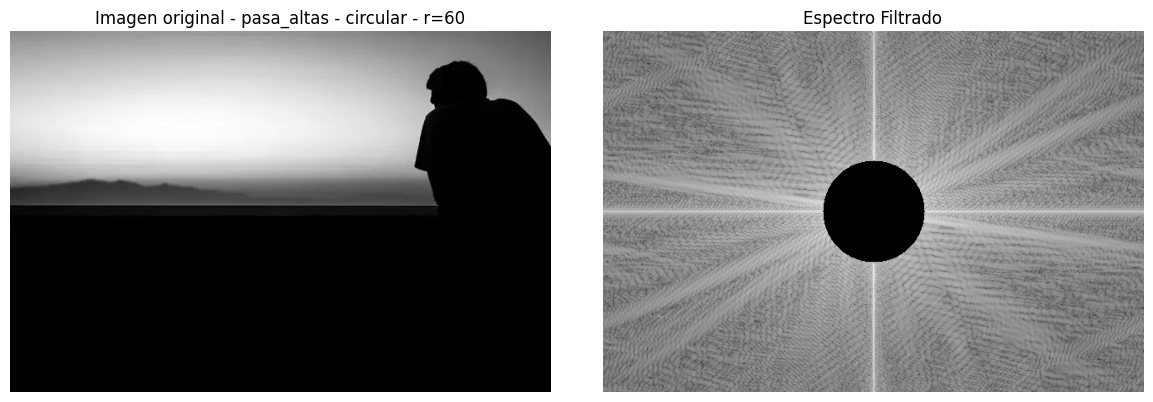

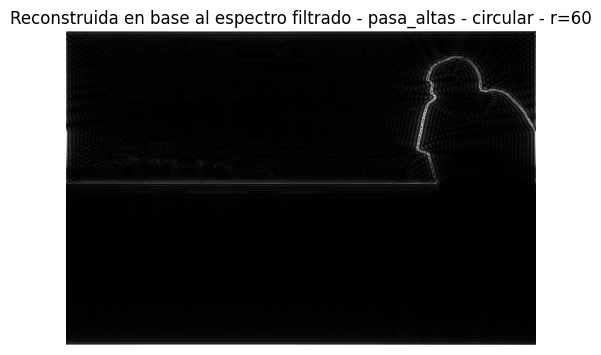

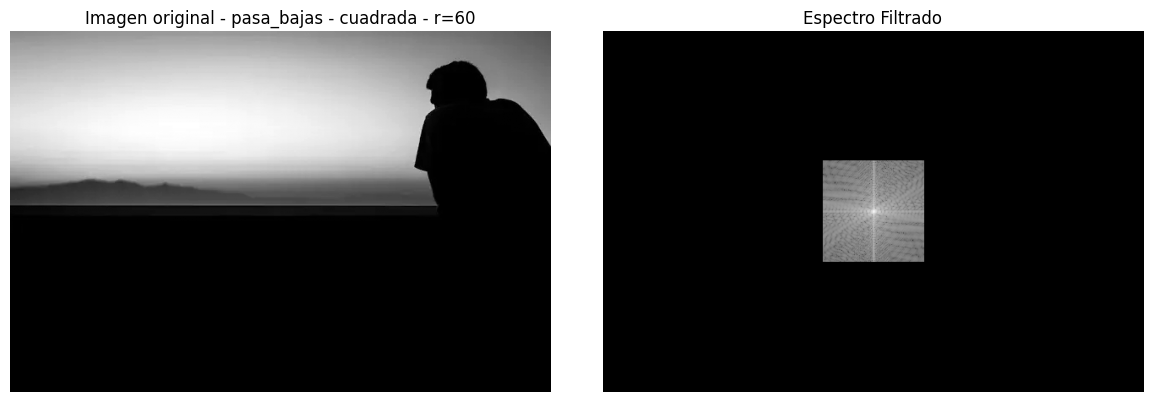

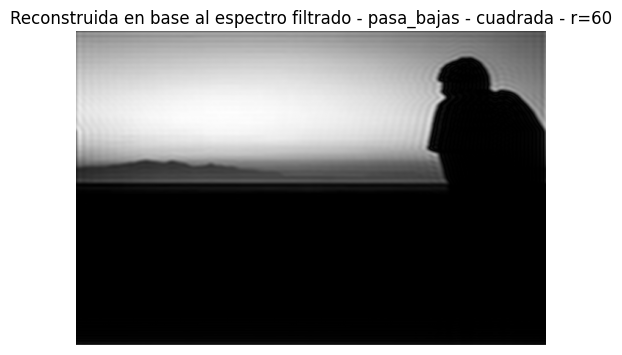

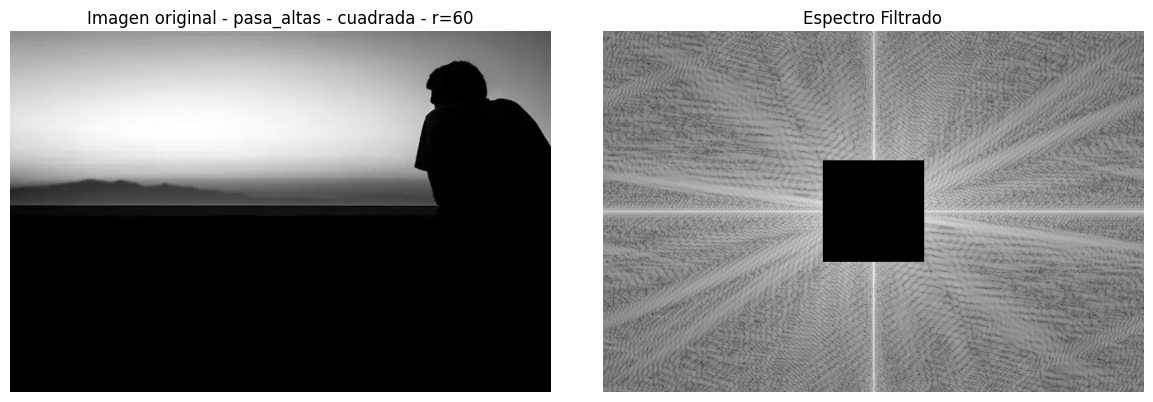

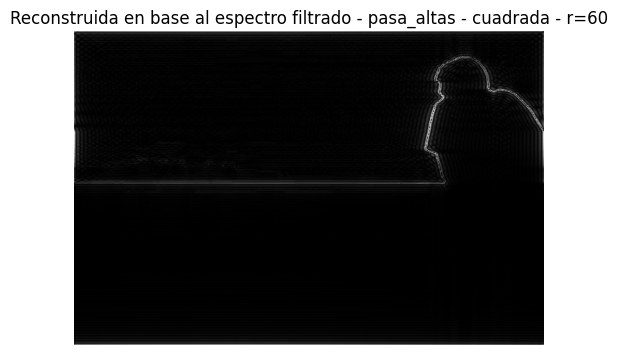

In [22]:
def aplicar_filtro_frecuencia(imagen, radio, tipo='pasa_bajas', forma='circular', mostrar=True):
    dft_shift = calcular_dft_centrada(imagen)
    mascara = crear_mascara_frecuencia(imagen.shape, radio, tipo=tipo, forma=forma)
    dft_filtrado = dft_shift * mascara

    if mostrar:
        mostrar_frecuencias(imagen, dft_filtrado, mostrar_fase=False, titulo=f"{tipo} - {forma} - r={radio}", titulo_magnitud='Espectro Filtrado')

    imagen_filtrada = reconstruir_imagen_idft(
        dft_filtrado, mostrar=mostrar,
        titulo=f"Reconstruida en base al espectro filtrado - {tipo} - {forma} - r={radio}"
    )

    return imagen_filtrada

# Cargar imagen en escala de grises
imagen_alta = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)
imagen_baja = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)

img1 = True
img2 = False
# Aplicar filtros
# En el caso de usar forma cuadrada el radio no es radio sino lado pero se entiende la idea
if img1:
    aplicar_filtro_frecuencia(imagen_alta, radio=60, tipo='pasa_bajas', forma='circular')
    aplicar_filtro_frecuencia(imagen_alta, radio=60, tipo='pasa_altas', forma='circular')
    aplicar_filtro_frecuencia(imagen_alta, radio=60, tipo='pasa_bajas', forma='cuadrada')
    aplicar_filtro_frecuencia(imagen_alta, radio=60, tipo='pasa_altas', forma='cuadrada')
if img2:
    
    aplicar_filtro_frecuencia(imagen_baja, radio=60, tipo='pasa_bajas', forma='circular')
    aplicar_filtro_frecuencia(imagen_baja, radio=60, tipo='pasa_altas', forma='circular')
    aplicar_filtro_frecuencia(imagen_baja, radio=60, tipo='pasa_bajas', forma='cuadrada')
    aplicar_filtro_frecuencia(imagen_baja, radio=60, tipo='pasa_altas', forma='cuadrada')

## (i)
**(i) ¿Cual es la relacion entre el patron de una imagen (orientacion, repeticion) y la simetrıa del
espectro? Ejercicio sugerido: Usar imagenes diagonales o repetitivas y analizar la simetrıa del
espectro.**

Se puede apreciar que en base a la orientacion de los patrones se puede determinar la orientacion de los picos en el dominio de frecuencia. Tambien es importante recalcar como se aprecia que en muchos casos la visualizacion de la magnitud tiene una orientacion contraria a la mostrada en la imagen. Por ejemplo si la imagen tiene un patron de lines horizontales, la magnitud va a tener un linea vertical. Tambien es importante remarcar que los patrones mantienen la simetria tanto en la imagen original como en la de magnitud.

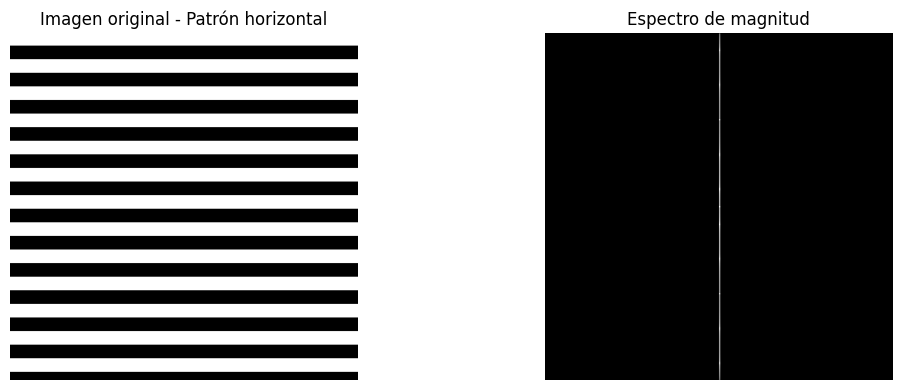

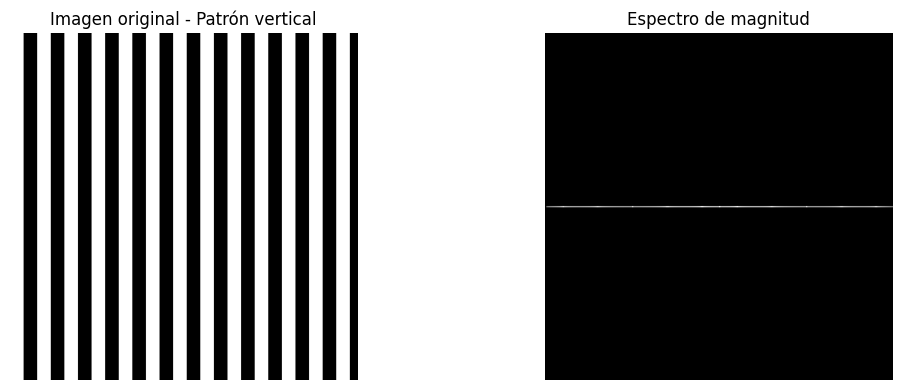

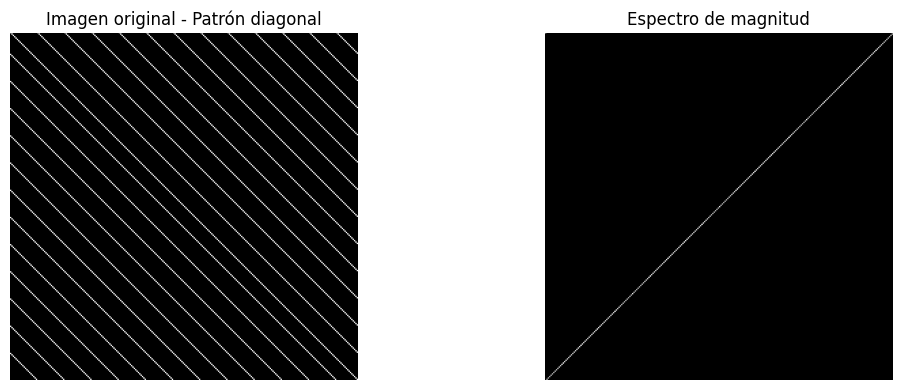

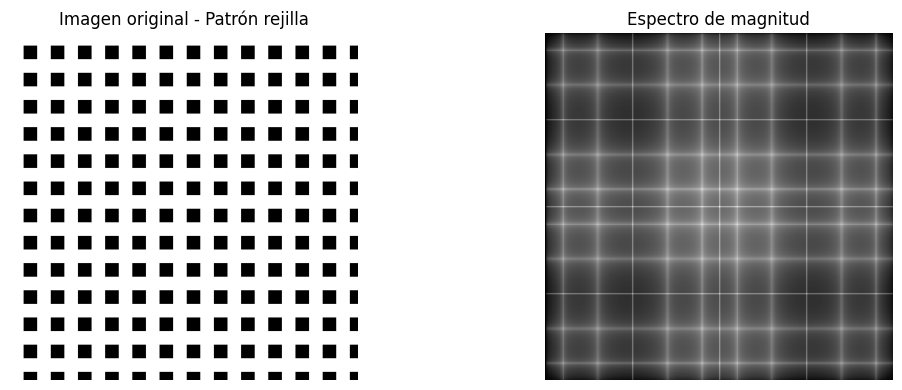

In [32]:
def crear_imagen_rayas(direccion='horizontal', size=256, frecuencia=10):
    img = np.zeros((size, size), dtype=np.uint8)

    if direccion == 'horizontal':
        for i in range(0, size, frecuencia*2):
            img[i:i+frecuencia] = 255

    elif direccion == 'vertical':
        for i in range(0, size, frecuencia*2):
            img[:, i:i+frecuencia] = 255

    elif direccion == 'diagonal':
        # Dibujar líneas diagonales periódicas de arriba-izquierda a abajo-derecha
        for offset in range(0, size, frecuencia*2):
            for i in range(size):
                j = (i + offset) % size
                if i < size and j < size:
                    img[i, j] = 255

    elif direccion == 'rejilla':
        for i in range(0, size, frecuencia*2):
            img[i:i+frecuencia, :] = 255
            img[:, i:i+frecuencia] = 255

    return img

direcciones = ['horizontal', 'vertical', 'diagonal', 'rejilla']

for dir in direcciones:
    img = crear_imagen_rayas(direccion=dir, frecuencia=10)
    dft = calcular_dft_centrada(img)
    mostrar_frecuencias(img, dft, mostrar_fase=False, titulo=f'Patrón {dir}')

## (j)
**(j) ¿Como puede usarse el dominio frecuencial para eliminar ruido periodico en una imagen? Ejercicio sugerido: Introducir ruido periodico artificialmente y diseñar un filtro para suprimirlo en el dominio de la frecuencia**

Es posible eliminar el ruido repetitivo o periodico dentro de una imagen ya que este se puede ver reflejado en la magnitud en pequeños puntos brillantes repetitivos. Para esto es necesario crear una mascara o filtro capaz de identificar y posteriormente eliminar (caso ideal) o atenuar aquellas frecuencias asociadas al ruido. En este caso concreto utilizamos un filtro el cual lleva a 0 aquellos valores en donde encontramos ruido (ya que nosotros aplicamos el ruido, tambien sabemos donde se encuentra y que patron sigue).

Esto es muy util para poder recuperar la calidad de aquellas imagenes que poseean mucho ruido o simplemente se requiera de una gran precision y calidad de imagen. 

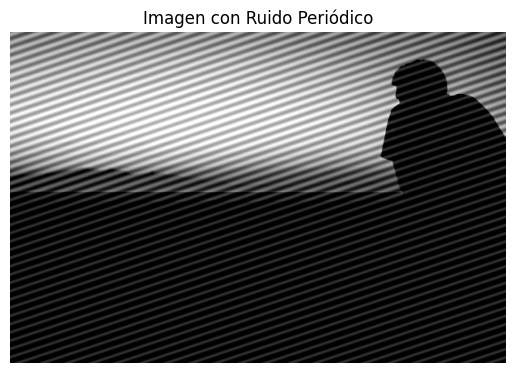

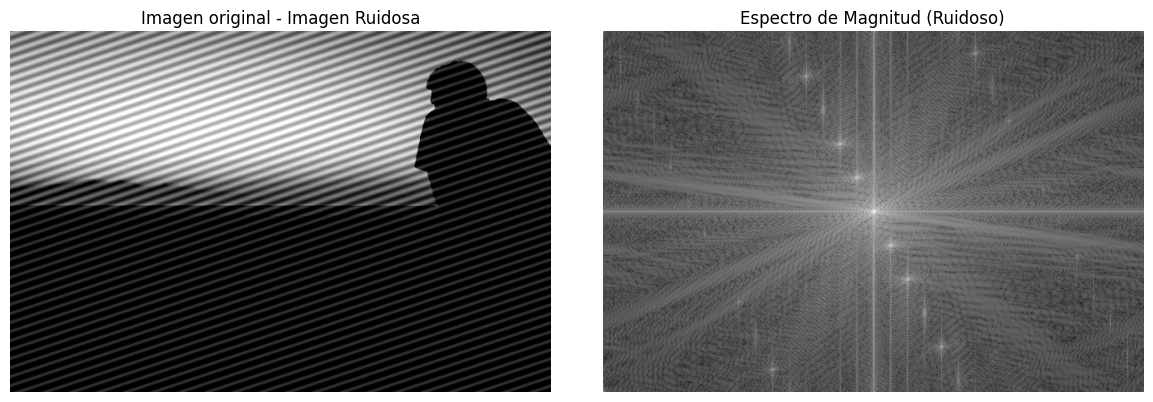

Dimensiones de la imagen: 427x640. Centro del espectro: (213, 320)
Para ruido (u=40,v=20), picos en DFT centrada (aprox): (253,340) y (173,300)
Para ruido (u=25,v=-55), picos en DFT centrada (aprox): (238,265) y (188,375)


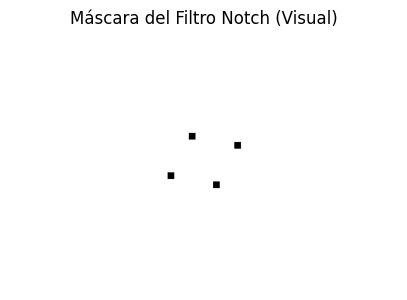

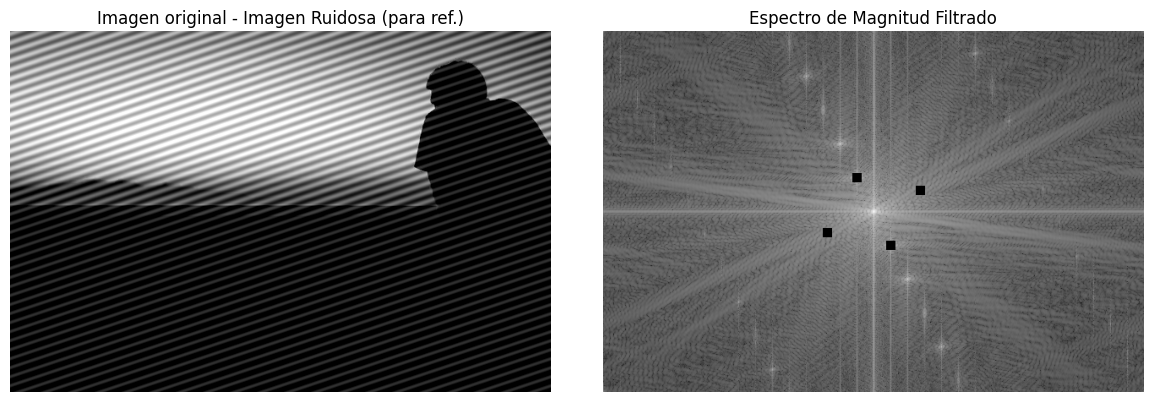

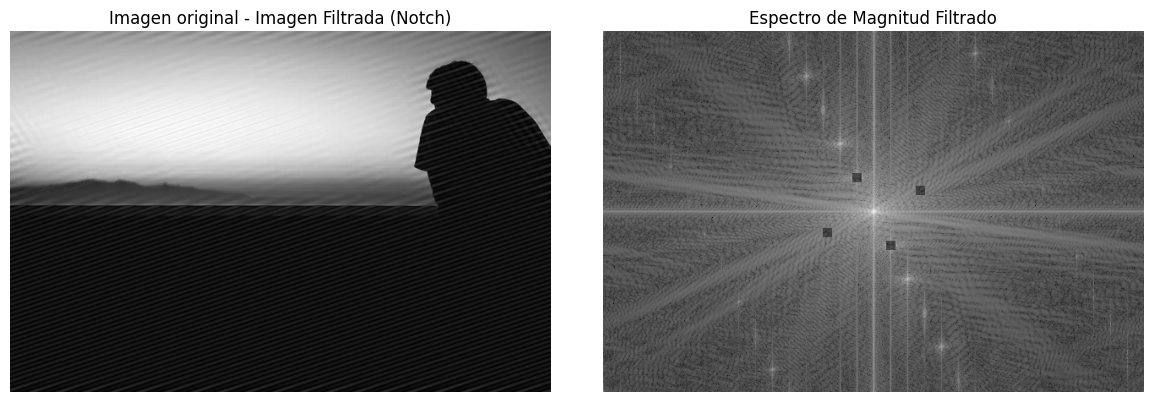

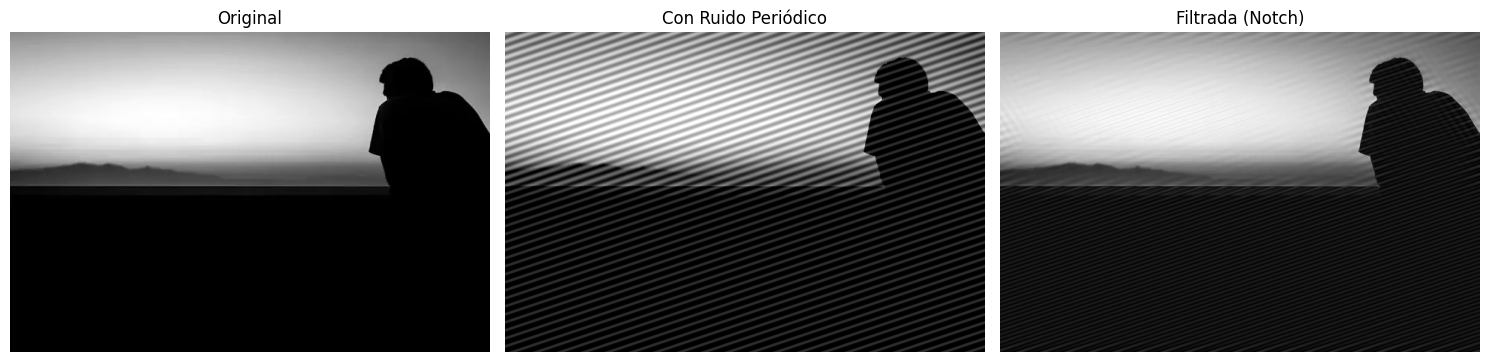

In [38]:
img_gray = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Introducir ruido periódico artificialmente
rows, cols = img_gray.shape
noisy_image = img_gray.copy().astype(np.float32)

# Frecuencias del ruido
# Determinarán la ubicación de los picos en el espectro.
u0_1, v0_1 = 40, 20  # Componente de ruido 1
u0_2, v0_2 = 25, -55 # Componente de ruido 2 (opcional, para más picos)

# Generar coordenadas x, y
x = np.arange(cols)
y = np.arange(rows)
xx, yy = np.meshgrid(x, y)

# Añadir ruido sinusoidal
# La amplitud (ej. 50) controla la "fuerza" del ruido
ruido1 = 50 * np.sin(2 * np.pi * (u0_1 * yy / rows + v0_1 * xx / cols))
#ruido2 = 40 * np.sin(2 * np.pi * (u0_2 * yy / rows + v0_2 * xx / cols)) # Ruido adicional

noisy_image += ruido1
#noisy_image += ruido2 

# Asegurar que la imagen ruidosa esté en el rango [0, 255]
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
show_image(noisy_image, title="Imagen con Ruido Periódico")

# Calcular DFT centrada de la imagen ruidosa y mostrar su espectro
dft_noisy_shift = calcular_dft_centrada(noisy_image)
mostrar_frecuencias(noisy_image, dft_noisy_shift, titulo='Imagen Ruidosa', titulo_magnitud='Espectro de Magnitud (Ruidoso)')

# Diseñar y aplicar el filtro notch
# Los picos de ruido estarán en (centro_r +/- u, centro_c +/- v) en la DFT centrada.
# Creamos una copia de la DFT para modificarla 
dft_filtrada = dft_noisy_shift.copy()

# Las frecuencias (u0, v0) del ruido se manifiestan como picos en:
# (rows//2 + u0, cols//2 + v0) y (rows//2 - u0, cols//2 - v0) debido a la simetría
centro_r, centro_c = rows // 2, cols // 2

# Lista de picos a eliminar [ (freq_vertical, freq_horizontal) ]
frecuencias_ruido = [(u0_1, v0_1)]
if 'ruido2' in locals(): # si se añadió el segundo ruido
    frecuencias_ruido.append((u0_2, v0_2))

radio_muesca = 5  # Radio de la región a atenuar alrededor de cada pico
mascara_visual = np.ones((rows, cols), dtype=np.float32) # Para visualizar la máscara

print(f"Dimensiones de la imagen: {rows}x{cols}. Centro del espectro: ({centro_r}, {centro_c})")

for u_noise, v_noise in frecuencias_ruido:
    puntos_a_eliminar = []
    
    # Asegurarse que u_noise y v_noise sean enteros para indexar
    u_idx = int(round(u_noise))
    v_idx = int(round(v_noise))

    # Pico positivo
    p1_r, p1_c = (centro_r + u_idx) % rows, (centro_c + v_idx) % cols # Modulo por si u_idx o v_idx son grandes
    puntos_a_eliminar.append((p1_r,p1_c))
    
    # Pico negativo simétrico
    p2_r, p2_c = (centro_r - u_idx + rows) % rows, (centro_c - v_idx + cols) % cols # Sumamos rows/cols antes del modulo para manejar negativos
    puntos_a_eliminar.append((p2_r,p2_c))

    print(f"Para ruido (u={u_noise},v={v_noise}), picos en DFT centrada (aprox): ({p1_r},{p1_c}) y ({p2_r},{p2_c})")
    
    for pr, pc in puntos_a_eliminar:
        # Definir la región de la muesca (notch) como un cuadrado
        r_start = np.clip(pr - radio_muesca, 0, rows -1).astype(int)
        r_end = np.clip(pr + radio_muesca + 1, 0, rows).astype(int)
        c_start = np.clip(pc - radio_muesca, 0, cols -1).astype(int)
        c_end = np.clip(pc + radio_muesca + 1, 0, cols).astype(int)
        
        # Poner a cero los coeficientes DFT en esta región
        dft_filtrada[r_start:r_end, c_start:c_end, :] = 0
        mascara_visual[r_start:r_end, c_start:c_end] = 0 # Actualizar máscara visual

# Mostrar la máscara del filtro notch
plt.figure(figsize=(5,5))
plt.imshow(mascara_visual, cmap='gray')
plt.title('Máscara del Filtro Notch (Visual)')
plt.axis('off')
plt.show()

# Mostrar el espectro de magnitud después de aplicar el filtro notch
mostrar_frecuencias(noisy_image, dft_filtrada, titulo='Imagen Ruidosa (para ref.)', titulo_magnitud='Espectro de Magnitud Filtrado')

# Reconstruir la imagen desde la DFT filtrada
imagen_filtrada = reconstruir_imagen_idft(dft_filtrada, mostrar=False, titulo="Imagen Filtrada (Notch)")
mostrar_frecuencias(imagen_filtrada, calcular_dft_centrada(imagen_filtrada), mostrar_fase=False, titulo='Imagen Filtrada (Notch)', titulo_magnitud='Espectro de Magnitud Filtrado')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Con Ruido Periódico')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_filtrada, cmap='gray')
plt.title('Filtrada (Notch)')
plt.axis('off')

plt.tight_layout()
plt.show()
